In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.chdir('..')
import functions.myfunctions as mf
import tidytcells as tt

In [ ]:
f2 = 'data/output/figures/'

In [3]:
vdj = pd.read_csv('data/vdj_cleaned_subset_for_MI.csv', index_col = 0)
vdj = vdj.loc[vdj['Epitope'] != 'KLGGALQAK'] # because too big - takes forever
vdj = mf.prepare_data(vdj, col1 = 'cdr3a_IMGTgaps', col2='cdr3b_IMGTgaps', type = 'cdr3')
print(vdj.shape)

for c in ['V-a', 'V-b', 'J-a', 'J-b']:
    print(c)
    vdj[c] = vdj.apply(
        lambda row: pd.NA if type(row[c]) != str else tt.tcr.standardise(
            gene_name=row[c],
            species=row['Species'],
            precision='gene'
        ),
        axis=1
    )
vdj00 = vdj.dropna(subset=['V-a', 'V-b', 'J-a', 'J-b'])
print('shape before tidytcells: ', vdj.shape, '; shape after tidytcells: ', vdj00.shape)

vdj = vdj00.copy()

(9785, 37)
V-a
V-b
J-a
J-b
shape before tidytcells:  (9785, 37) ; shape after tidytcells:  (9785, 37)


In [4]:
vdj = vdj.drop_duplicates(subset = ['V-a','J-a','cdr3a_IMGTgaps_padded','V-b','J-b','cdr3b_IMGTgaps_padded', 'Epitope'])
print(vdj.shape)

(9744, 37)


In [5]:
_10x_ref = 'https://www.10xgenomics.com/resources/application-notes/a-new-way-of-exploring-immunity-linking-highly-multiplexed-antigen-recognition-to-immune-repertoire-and-phenotype/#'
vdj['Reference'] = vdj['Reference'].replace(_10x_ref, '10xGenomics').fillna('unknown')

X = vdj[['Epitope','Reference']].value_counts()
print(X.shape)
X = X.loc[X > 2]
X = X.reset_index()

(78,)


In [6]:
epset = []
for epp in vdj['Epitope'].unique():
    allowed_refs = X.loc[X['Epitope'] == epp]['Reference'].tolist()
    pp = vdj.loc[vdj['Epitope'] == epp]
    pp = pp.loc[pp['Reference'].isin(allowed_refs)].sort_values(by = 'Reference')
    epset.append(pp)
epset = pd.concat(epset)
assert epset.shape[0] == X[0].sum()

vdj = epset.copy()

In [7]:
vdj.shape

(9713, 37)

In [8]:
tanno = pd.read_csv('data/tanno_A1naive_subset_for_MI.csv', index_col=0)
epset = mf.prepare_data(tanno, col1='cdr3a_IMGTgaps', col2='cdr3b_IMGTgaps', max_len1=19, max_len2=19)
ind = 'Tanno::A1::naive'

for c in ['VL', 'VH', 'JL', 'JH']:
    print(c)
    epset[c] = epset.apply(
        lambda row: pd.NA if type(row[c]) != str else tt.tcr.standardise(
            gene_name=row[c],
            species='HomoSapiens',
            precision='gene'
        ),
        axis=1
    )
epset00 = epset.dropna(subset=['VL', 'VH', 'JL', 'JH'], how='any')
print('shape before tidytcells: ', epset.shape, '; shape after tidytcells: ', epset00.shape)

tanno = epset00.copy()
tanno = tanno.drop_duplicates(subset = ['VL', 'VH', 'JL', 'JH', 'cdr3a_IMGTgaps_padded', 'cdr3b_IMGTgaps_padded'])
tanno.shape

set max length for cdr3a_IMGTgaps: cleaning up the dataset
set max length for cdr3b_IMGTgaps: cleaning up the dataset
VL
VH
JL
JH
shape before tidytcells:  (14745, 24) ; shape after tidytcells:  (14745, 24)


(14745, 24)

In [9]:
def get_gap_counts(mydf, mycol):
    cdr3_res = [104,105,106,107,108,109,110,111,'111.1','111.2','112.2','112.1',112,113,114,115,116,117,118]
    cdr3_res = [str(x) for x in cdr3_res]

    x = pd.DataFrame(mydf[mycol].str.split(', '))
    X = pd.DataFrame()
    X[cdr3_res] = pd.DataFrame(x[mycol].tolist(), index= x.index)

    gaps = {}

    for c in cdr3_res:
        counts = X[c].value_counts()
        if '-' in counts.index:
            counts = counts.loc['-']
        else:
            counts = 0

        gaps[c] = counts/X.shape[0]
    return gaps

In [10]:
cdr3_res = [104,105,106,107,108,109,110,111,'111.1','111.2','112.2','112.1',112,113,114,115,116,117,118]

gap_counts_alpha = {}
gap_counts_beta = {}

gap_counts_alpha['background'] = get_gap_counts(vdj, 'cdr3a_IMGTgaps_padded')
gap_counts_beta['background'] = get_gap_counts(vdj, 'cdr3b_IMGTgaps_padded')

for ep in vdj['Epitope'].unique():
    epset = vdj.loc[vdj['Epitope'] == ep]
    gap_counts_alpha[ep] = get_gap_counts(epset, 'cdr3a_IMGTgaps_padded')
    gap_counts_beta[ep] = get_gap_counts(epset, 'cdr3b_IMGTgaps_padded')


In [11]:
gap_counts_alpha['Tanno::A1::naive'] = get_gap_counts(tanno, 'cdr3a_IMGTgaps_padded')
gap_counts_beta['Tanno::A1::naive'] = get_gap_counts(tanno, 'cdr3b_IMGTgaps_padded')

In [12]:
gap_counts_alpha = pd.DataFrame(gap_counts_alpha).T
gap_counts_beta = pd.DataFrame(gap_counts_beta).T

In [13]:
gap_counts_alpha

,104,105,106,107,108,109,110,111,111.1,111.2,112.2,112.1,112,113,114,115,116,117,118
background,0.0,0.0,0.0,0.000000,0.001647,0.041388,0.291053,0.688974,0.980130,0.994029,0.926902,0.865335,0.510141,0.131679,0.005560,0.000309,0.000000,0.0,0.0
ELAGIGILTV,0.0,0.0,0.0,0.000000,0.010695,0.171123,0.486631,0.796791,0.970588,0.991979,0.959893,0.925134,0.663102,0.288770,0.042781,0.002674,0.000000,0.0,0.0
GILGFVFTL,0.0,0.0,0.0,0.000000,0.002159,0.014031,0.223421,0.529412,0.968699,0.985969,0.840259,0.801403,0.330815,0.045872,0.005936,0.000540,0.000000,0.0,0.0
NLVPMVATV,0.0,0.0,0.0,0.000000,0.000000,0.017241,0.385057,0.729885,0.982759,0.997126,0.959770,0.856322,0.502874,0.192529,0.005747,0.000000,0.000000,0.0,0.0
GLCTLVAML,0.0,0.0,0.0,0.000000,0.000000,0.078947,0.464912,0.877193,0.991228,1.000000,0.976608,0.929825,0.733918,0.339181,0.000000,0.000000,0.000000,0.0,0.0
SSLENFRAYV,0.0,0.0,0.0,0.000000,0.000000,0.002865,0.083095,0.770774,0.997135,1.000000,0.974212,0.876791,0.587393,0.034384,0.000000,0.000000,0.000000,0.0,0.0
ASNENMETM,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.112245,0.540816,0.994898,1.000000,0.938776,0.836735,0.331633,0.005102,0.000000,0.000000,0.000000,0.0,0.0
YLQPRTFLL,0.0,0.0,0.0,0.000000,0.000000,0.033233,0.574018,0.824773,0.981873,0.993958,0.957704,0.900302,0.694864,0.474320,0.003021,0.000000,0.000000,0.0,0.0
LLWNGPMAV,0.0,0.0,0.0,0.000000,0.000000,0.489362,0.727660,0.910638,1.000000,1.000000,0.991489,0.961702,0.838298,0.642553,0.004255,0.000000,0.000000,0.0,0.0
CINGVCWTV,0.0,0.0,0.0,0.000000,0.004425,0.057522,0.265487,0.561947,0.973451,1.000000,0.884956,0.752212,0.433628,0.163717,0.035398,0.000000,0.000000,0.0,0.0


In [14]:
all_subsets = sorted(vdj['Epitope'].unique().tolist())+ ['background', 'Tanno::A1::naive']

In [15]:
import statsmodels.api as sm


def simple_regplot(x_name,
    x, y, n_std=2, n_pts=100, ax=None, scatter_kws=None, line_kws=None, ci_kws=None
):
    """ Draw a regression line with error interval. """
    ax = plt.gca() if ax is None else ax

    # calculate best-fit line and interval
    x_fit = sm.add_constant(x)
    fit_results = sm.OLS(y, x_fit).fit()

    print(fit_results.summary())
    pval = fit_results.f_pvalue
    Rsq = fit_results.rsquared
    Rsq_adj = fit_results.rsquared_adj
    if (pval<0.05):
        line_kws={'color':'red'}
        ci_kws={'color':'red'}
    else:
        line_kws={'color':'k'}
        ci_kws={'color':'k'}

    eval_x = sm.add_constant(np.linspace(np.min(x), np.max(x), n_pts))
    pred = fit_results.get_prediction(eval_x)

    # draw the fit line and 95% CI
    ci_kws = {} if ci_kws is None else ci_kws
    df_predictions = pred.summary_frame(alpha=0.05)
    ax.fill_between(
        eval_x[:, 1],
        df_predictions.mean_ci_lower,
        df_predictions.mean_ci_upper,
        alpha=0.5,
        **ci_kws,
    )
    line_kws = {} if line_kws is None else line_kws
    h = ax.plot(eval_x[:, 1], pred.predicted_mean, **line_kws)

    return pval, Rsq, Rsq_adj

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.164
Model:                            OLS   Adj. R-squared:                  0.162
Method:                 Least Squares   F-statistic:                     89.04
Date:                Sat, 19 Apr 2025   Prob (F-statistic):           2.02e-19
Time:                        19:53:11   Log-Likelihood:                -184.70
No. Observations:                 456   AIC:                             373.4
Df Residuals:                     454   BIC:                             381.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4305      0.022     19.174      0.0

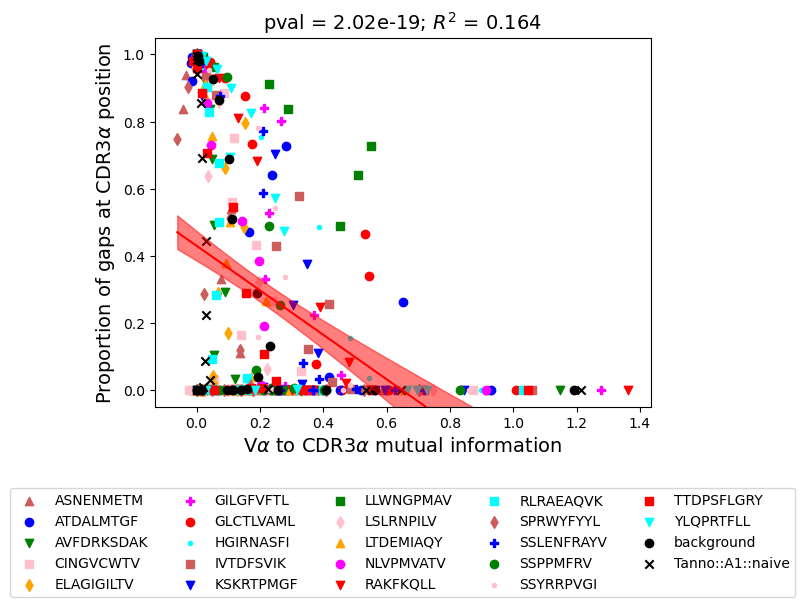

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.122
Model:                            OLS   Adj. R-squared:                  0.120
Method:                 Least Squares   F-statistic:                     62.99
Date:                Sat, 19 Apr 2025   Prob (F-statistic):           1.64e-14
Time:                        19:53:12   Log-Likelihood:                -173.80
No. Observations:                 456   AIC:                             351.6
Df Residuals:                     454   BIC:                             359.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3695      0.023     16.266      0.0

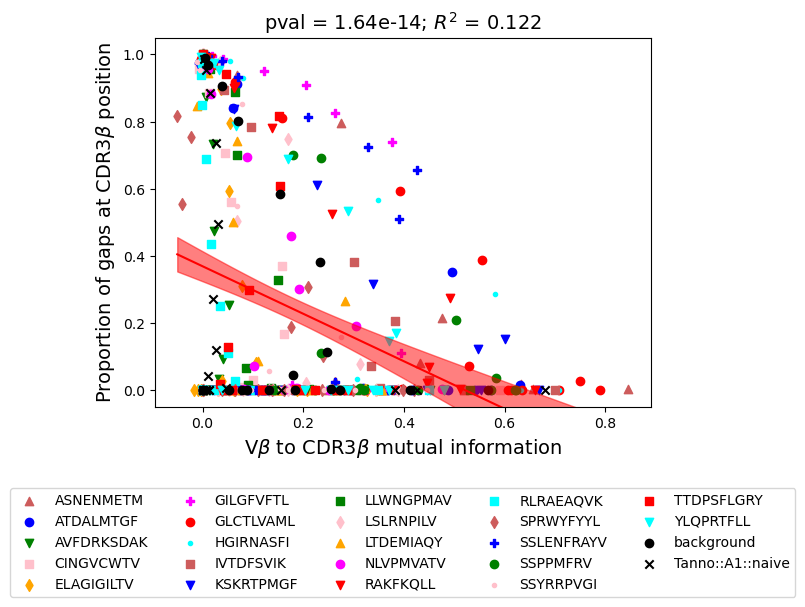

In [16]:
cdr3_res = [104,105,106,107,108,109,110,111,'111.1','111.2','112.2','112.1',112,113,114,115,116,117,118]

all_mi = pd.read_csv('data/output/mutual_info/estimated_mutual_info_all_epitopes_VJ_to_CDR3_by_pos_all_epitopes_w_studyspecific_shuffle_wdupl.csv', index_col=0)

epitopes_a0 = all_mi.loc[all_mi['pair'] == 'Va-CDR3a']
epitopes_a = pd.DataFrame()
for ep in all_subsets:
    epdf = epitopes_a0.loc[epitopes_a0['epitope'] == ep]
    diff = epdf.loc[epdf['type'] == 'real'][[c for c in epdf.columns if c not in ['epitope', 'type','pair']]].values - epdf.loc[epdf['type'] == 'shuffle'][[c for c in epdf.columns if c not in ['epitope', 'type','pair']]].values
    diff = pd.DataFrame(diff, index=[ep])
    diff['epitope'] = ep
    epitopes_a = pd.concat([epitopes_a, diff])

epitopes_a = epitopes_a.drop('epitope', axis=1)
epitopes_a.columns = [str(x) for x in cdr3_res]

styles = ['^', 'o', 'v', 's', 'd', 'P','o','.','s','v', 's', 'd','^', 'o', 'v', 's', 'd', 'P','o','.','s','v','o','x']
colors = ['indianred','blue','g','pink','orange','fuchsia','red','cyan',
          'indianred','blue','g','pink','orange','fuchsia','red','cyan',
          'indianred','blue','g','pink', 'red','cyan','k','k']

ax = plt.subplot()
x = []
y = []
for i, ep in enumerate(all_subsets):
    ax.scatter(epitopes_a.loc[ep], gap_counts_alpha.loc[ep], 
                marker=styles[i], c = colors[i], label = ep)
    x.append(epitopes_a.loc[ep])
    y.append(gap_counts_alpha.loc[ep])
x = pd.concat(x)
y = pd.concat(y)
pval, rsq, _ = simple_regplot('V$\alpha$ to CDR3$\alpha$ mutual information', x, y, ax=ax)
plt.ylim(-0.05, 1.05)
plt.title('pval = ' + '{:.2e}'.format(pval) + r'; $R^2$ = ' + str(rsq.round(3)), fontsize=14)
plt.xlabel(r'V$\alpha$ to CDR3$\alpha$ mutual information', fontsize = 14)
plt.ylabel(r'Proportion of gaps at CDR3$\alpha$ position', fontsize = 14)
plt.legend(bbox_to_anchor = [0.5,-.2], ncols = 5, loc='upper center')
plt.savefig(f2 + 'MI_vs_gaps_Va_CDR3a_wdupl.png', bbox_inches = 'tight')
plt.show()

epitopes_b0 = all_mi.loc[all_mi['pair'] == 'Vb-CDR3b']
epitopes_b = pd.DataFrame()
for ep in all_subsets:
    epdf = epitopes_b0.loc[epitopes_b0['epitope'] == ep]
    diff = epdf.loc[epdf['type'] == 'real'][[c for c in epdf.columns if c not in ['epitope', 'type','pair']]].values - epdf.loc[epdf['type'] == 'shuffle'][[c for c in epdf.columns if c not in ['epitope', 'type','pair']]].values
    diff = pd.DataFrame(diff, index = [ep])
    diff['epitope'] = ep
    epitopes_b = pd.concat([epitopes_b, diff])
epitopes_b = epitopes_b.drop('epitope', axis=1)
epitopes_b.columns = [str(x) for x in cdr3_res]

ax = plt.subplot()
x = []
y = []
for i, ep in enumerate(all_subsets):
    ax.scatter(epitopes_b.loc[ep], gap_counts_beta.loc[ep], 
                marker=styles[i], c = colors[i], label = ep)
    x.append(epitopes_b.loc[ep])
    y.append(gap_counts_beta.loc[ep])
x = pd.concat(x)
y = pd.concat(y)
pval, rsq, _ = simple_regplot('V$\beta$ to CDR3$\beta$ mutual information', x, y, ax=ax)
plt.ylim(-0.05, 1.05)
plt.title('pval = ' + '{:.2e}'.format(pval) + r'; $R^2$ = ' + str(rsq.round(3)), fontsize=14)
plt.xlabel(r'V$\beta$ to CDR3$\beta$ mutual information', fontsize = 14)
plt.ylabel(r'Proportion of gaps at CDR3$\beta$ position', fontsize = 14)
plt.legend(bbox_to_anchor = [0.5,-.2], ncols = 5, loc='upper center')
plt.savefig(f2 + 'MI_vs_gaps_Vb_CDR3b_wdupl.png', bbox_inches = 'tight')
plt.show()


                            OLS Regression Results                            
Dep. Variable:              gaps_beta   R-squared:                       0.028
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     13.24
Date:                Sat, 19 Apr 2025   Prob (F-statistic):           0.000306
Time:                        19:53:13   Log-Likelihood:                -196.87
No. Observations:                 456   AIC:                             397.7
Df Residuals:                     454   BIC:                             406.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2890      0.021     13.755      0.0

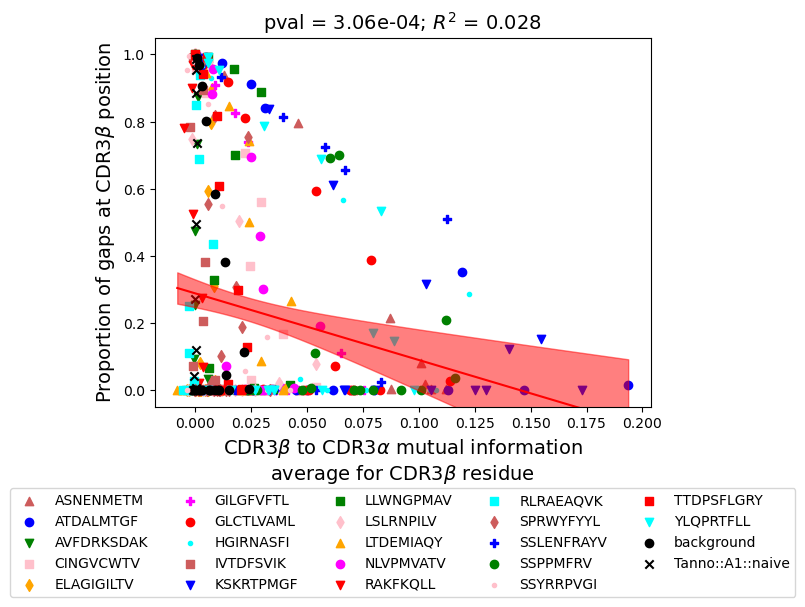

                            OLS Regression Results                            
Dep. Variable:             gaps_alpha   R-squared:                       0.082
Model:                            OLS   Adj. R-squared:                  0.080
Method:                 Least Squares   F-statistic:                     40.67
Date:                Sat, 19 Apr 2025   Prob (F-statistic):           4.45e-10
Time:                        19:53:14   Log-Likelihood:                -205.97
No. Observations:                 456   AIC:                             415.9
Df Residuals:                     454   BIC:                             424.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3720      0.022     17.085      0.0

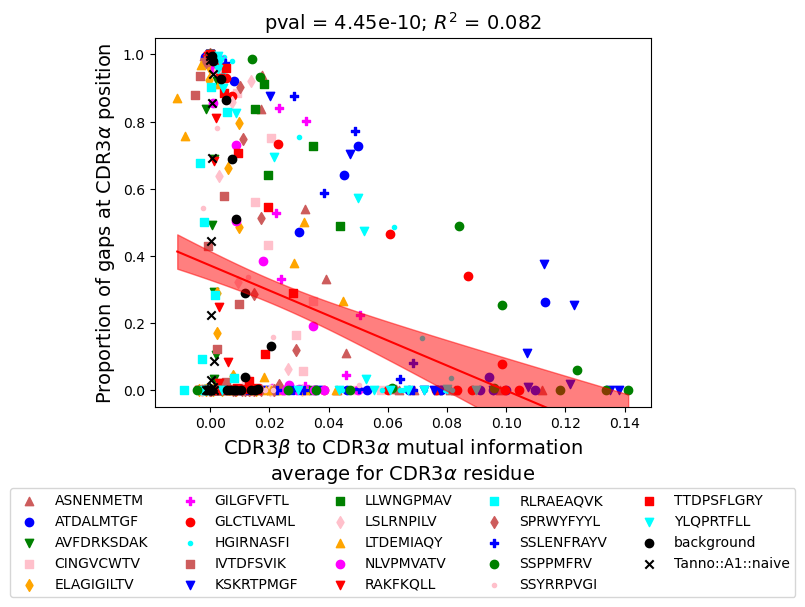

In [17]:
all_epitopes = pd.read_csv('data/output/mutual_info/estimated_mutual_info_all_epitopes_CDR3ab_by_pos_all_epitopes_w_studyspecific_shuffle_wdupl.csv', index_col = 0)
# print(all_epitopes)
diffs={}

for x, ep in enumerate(all_subsets):
    epdf = all_epitopes.loc[all_epitopes['epitope'] == ep]
    diff = epdf.loc[epdf['type'] == 'real'][[c for c in epdf.columns if c not in ['epitope', 'type']]].values - epdf.loc[epdf['type'] == 'shuffle'][[c for c in epdf.columns if c not in ['epitope', 'type']]].values
    X = pd.DataFrame(diff.reshape(19,19))

    X.columns=[str(x) for x in cdr3_res]
    X.index=[str(x) for x in cdr3_res]
    diffs[ep] = X

alpha = {}
beta = {}
for i, ep in enumerate(all_subsets):
    mean_alpha = diffs[ep].mean(axis=1)
    mean_alpha.name = 'mean_alpha'
    mean_beta = diffs[ep].mean(axis=0)
    mean_beta.name = 'mean_beta'
    gaps_beta = gap_counts_beta.loc[ep]
    gaps_beta.name = 'gaps_beta'
    gaps_alpha = gap_counts_alpha.loc[ep]
    gaps_alpha.name = 'gaps_alpha'

    alpha[ep] = pd.merge(mean_alpha, gaps_alpha, left_index=True, right_index=True)
    beta[ep] = pd.merge(mean_beta, gaps_beta, left_index=True, right_index=True)

ax = plt.subplot()
x = []
y = []
for i, ep in enumerate(all_subsets):
    ax.scatter(beta[ep]['mean_beta'], beta[ep]['gaps_beta'], 
                marker=styles[i], c = colors[i], label = ep)
    x.append(beta[ep]['mean_beta'])
    y.append(beta[ep]['gaps_beta'])
x = pd.concat(x)
y = pd.concat(y)
pval, rsq, _ = simple_regplot(r'CDR3$\beta$ to CDR3$\alpha$' + ' mutual information\naverage for' + r'CDR3$\beta$ residue', x, y, ax=ax)
plt.ylim(-0.05, 1.05)
plt.title('pval = ' + '{:.2e}'.format(pval) + r'; $R^2$ = ' + str(rsq.round(3)), fontsize=14)
plt.xlabel(r'CDR3$\beta$ to CDR3$\alpha$' + ' mutual information\naverage for ' + r'CDR3$\beta$ residue', fontsize = 14)
plt.ylabel(r'Proportion of gaps at CDR3$\beta$ position', fontsize = 14)
plt.legend(bbox_to_anchor = [0.5,-.2], ncols = 5, loc='upper center')
plt.savefig(f2 + 'MI_vs_gaps_CDR3ab_CDR3b_gaps_wdupl.png', bbox_inches = 'tight')
plt.show()

ax = plt.subplot()
x = []
y = []
for i, ep in enumerate(all_subsets):
    ax.scatter(alpha[ep]['mean_alpha'], alpha[ep]['gaps_alpha'], 
                marker=styles[i], c = colors[i], label = ep)
    x.append(alpha[ep]['mean_alpha'])
    y.append(alpha[ep]['gaps_alpha'])
x = pd.concat(x)
y = pd.concat(y)
pval, rsq, _ = simple_regplot(r'CDR3$\beta$ to CDR3$\alpha$' + ' mutual information\naverage for ' + r'CDR3$\alpha$ residue', x, y, ax=ax)
plt.title('pval = ' + '{:.2e}'.format(pval) + r'; $R^2$ = ' + str(rsq.round(3)), fontsize=14)
plt.ylim(-0.05, 1.05)
plt.xlabel(r'CDR3$\beta$ to CDR3$\alpha$' + ' mutual information\naverage for ' + r'CDR3$\alpha$ residue', fontsize = 14)
plt.ylabel(r'Proportion of gaps at CDR3$\alpha$ position', fontsize = 14)
plt.legend(bbox_to_anchor = [0.5,-.2], ncols = 5, loc='upper center')
plt.savefig(f2 + 'MI_vs_gaps_CDR3ab_CDR3a_gaps_wdupl.png', bbox_inches = 'tight')
plt.show()
